# Configurable Greediness to Exhaustion

Test one variable only: how aggressively we take currently available positive exact-score rewards. Every policy sees the same random seed colorings. No negative-reward moves, structural filtering, flexibility objective, or tabu search are used.

A run is exhausted when no edge flip has positive exact score reward. Because every applied move has positive reward, score decreases monotonically and the final score is also the minimum observed score.

In [1]:
# Experiment Configuration

RANDOM_SEED = 202_608_085
N_VERTICES = 43
NUMBER_OF_COLORINGS = 25

# 1.00 is ordinary maximum-delta-S greedy.
# 0.00 is the smallest edge flip that still decreases S.
GREEDINESS_LEVELS = (1.00, 0.75, 0.50, 0.25, 0.00)

MAXIMUM_STEPS = 5_000
REPORT_EVERY_RUNS = 5

RUN_NAME = "configurable-greediness-exhaustion-001"
DATABASE_FILENAME = "configurable_greediness_exhaustion.sqlite3"

In [2]:
# Imports and Project Setup

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey import (
    RConfigurableGreedyPolicy,
    RConfigurableGreedyPolicyConfig,
    REnvironment,
    REnvironmentConfig,
    RGraph,
    RMonochromaticObjective,
    RNullMemory,
    RProblem,
    RRandomConstruction,
    RSQLiteArchive,
)

project_root = Path.cwd().resolve()

if project_root.name == "notebooks":
    project_root = project_root.parent

if not (project_root / "ramsey").is_dir():
    raise RuntimeError(
        "Run this notebook from the RamseyNumber root "
        "or notebooks directory."
    )

DATABASE_PATH = (
    project_root
    / "data"
    / "experiments"
    / DATABASE_FILENAME
)

In [3]:
# Graph and Matched Random Seed Colorings

graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
construction_rng = np.random.default_rng(RANDOM_SEED)
construction = RRandomConstruction(construction_rng)

seed_colorings = [
    construction.construct(graph)
    for _ in range(NUMBER_OF_COLORINGS)
]

print("Edges:", f"{graph.number_of_edges:,}")
print("K5s:", f"{graph.subgraph_index(5).clique_count:,}")
print("Matched seed colorings:", NUMBER_OF_COLORINGS)
print("Greediness levels:", GREEDINESS_LEVELS)
print("Maximum steps:", MAXIMUM_STEPS)
print("Database:", DATABASE_PATH.resolve())

Edges: 903
K5s: 962,598
Matched seed colorings: 25
Greediness levels: (1.0, 0.75, 0.5, 0.25, 0.0)
Maximum steps: 5000
Database: C:\code\RamseyNumber\data\experiments\configurable_greediness_exhaustion.sqlite3


In [4]:
# One Monotonic Run to Positive-Reward Exhaustion

def run_to_exhaustion(seed_coloring, greediness, rng):
    environment = REnvironment(
        graph=graph,
        objective=RMonochromaticObjective(),
        memory=RNullMemory(),
        config=REnvironmentConfig(
            max_steps=MAXIMUM_STEPS,
            use_aspiration=False,
        ),
    )
    environment.reset(seed_coloring)

    policy = RConfigurableGreedyPolicy(
        rng=rng,
        config=RConfigurableGreedyPolicyConfig(
            greediness=greediness,
        ),
    )

    initial_score = environment.state.score
    selected_rewards = []
    positive_action_counts = []
    maximum_available_rewards = []
    exhausted = False
    wall_maximum_reward = None

    while not (environment.terminated or environment.truncated):
        analysis = environment.analyze_actions()
        rewards = analysis.action_analysis.immediate_rewards
        available_rewards = rewards[analysis.available_mask]
        positive_count = int(np.count_nonzero(available_rewards > 0))

        if positive_count == 0:
            exhausted = True
            wall_maximum_reward = int(available_rewards.max())
            break

        edge = policy.select_action(environment)
        decision = policy.last_decision

        if decision is None:
            raise RuntimeError("Policy failed to record its decision.")

        result = environment.step(
            edge,
            full_analysis=True,
        )

        if result.immediate_reward <= 0:
            raise RuntimeError(
                "Configurable-greedy run applied a nonpositive action."
            )

        selected_rewards.append(result.immediate_reward)
        positive_action_counts.append(decision.positive_action_count)
        maximum_available_rewards.append(decision.maximum_positive_reward)

    return {
        "initial_score": initial_score,
        "final_score": environment.state.score,
        "final_coloring": environment.state.coloring_snapshot(),
        "steps": environment.step_number,
        "exhausted": exhausted,
        "solved": environment.terminated,
        "truncated": environment.truncated,
        "wall_maximum_reward": wall_maximum_reward,
        "selected_rewards": np.asarray(selected_rewards, dtype=np.int32),
        "positive_action_counts": np.asarray(
            positive_action_counts,
            dtype=np.int32,
        ),
        "maximum_available_rewards": np.asarray(
            maximum_available_rewards,
            dtype=np.int32,
        ),
    }

In [5]:
# Run Every Greediness Level on the Same Seed Batch

existing_archive = globals().get("archive")

if existing_archive is not None:
    existing_archive.close()

archive = RSQLiteArchive(DATABASE_PATH)
run_rows = []
all_results = {}
experiment_start = perf_counter()

for level_number, greediness in enumerate(GREEDINESS_LEVELS):
    level_start = perf_counter()
    level_results = []

    print()
    print(f"GREEDINESS {greediness:.2f}")
    print("-" * 48)

    for coloring_number, seed_coloring in enumerate(seed_colorings):
        action_rng = np.random.default_rng(
            RANDOM_SEED
            + 100_000 * (level_number + 1)
            + coloring_number
        )

        result = run_to_exhaustion(
            seed_coloring,
            greediness,
            action_rng,
        )
        level_results.append(result)

        record = archive.save_coloring(
            result["final_coloring"],
            run_name=f"{RUN_NAME}-g{greediness:.2f}",
            iteration=coloring_number,
        )

        rewards = result["selected_rewards"]
        run_rows.append({
            "greediness": greediness,
            "coloring": coloring_number,
            "initial_score": result["initial_score"],
            "final_score": result["final_score"],
            "steps": result["steps"],
            "mean_selected_reward": (
                float(rewards.mean()) if rewards.size else 0.0
            ),
            "exhausted": result["exhausted"],
            "solved": result["solved"],
            "truncated": result["truncated"],
            "wall_maximum_reward": result["wall_maximum_reward"],
            "archive_id": record.coloring_id,
        })

        completed = coloring_number + 1

        if (
            completed % REPORT_EVERY_RUNS == 0
            or completed == NUMBER_OF_COLORINGS
        ):
            recent = level_results[-REPORT_EVERY_RUNS:]
            recent_finals = [item["final_score"] for item in recent]
            print(
                f"{completed:3d}/{NUMBER_OF_COLORINGS} | "
                f"recent mean final={np.mean(recent_finals):7.2f} | "
                f"recent min={min(recent_finals):4d}"
            )

    all_results[greediness] = level_results
    level_elapsed = perf_counter() - level_start
    finals = np.asarray(
        [item["final_score"] for item in level_results],
        dtype=np.int32,
    )
    print(
        f"COMPLETE | mean={finals.mean():.2f} | "
        f"median={np.median(finals):.1f} | "
        f"min={finals.min()} | time={level_elapsed:.1f}s"
    )

experiment_elapsed = perf_counter() - experiment_start
runs = pd.DataFrame(run_rows)

print()
print("Total elapsed:", f"{experiment_elapsed:.1f}s")


GREEDINESS 1.00
------------------------------------------------
  5/25 | recent mean final= 308.60 | recent min= 297
 10/25 | recent mean final= 297.20 | recent min= 257
 15/25 | recent mean final= 296.40 | recent min= 263
 20/25 | recent mean final= 283.80 | recent min= 268
 25/25 | recent mean final= 306.40 | recent min= 273
COMPLETE | mean=298.48 | median=300.0 | min=257 | time=14.3s

GREEDINESS 0.75
------------------------------------------------
  5/25 | recent mean final= 292.00 | recent min= 272
 10/25 | recent mean final= 291.40 | recent min= 266
 15/25 | recent mean final= 287.40 | recent min= 260
 20/25 | recent mean final= 295.20 | recent min= 267
 25/25 | recent mean final= 279.00 | recent min= 260
COMPLETE | mean=289.00 | median=293.0 | min=260 | time=19.2s

GREEDINESS 0.50
------------------------------------------------
  5/25 | recent mean final= 300.60 | recent min= 284
 10/25 | recent mean final= 270.00 | recent min= 224
 15/25 | recent mean final= 266.20 | recent 

In [6]:
# Final Exhaustion Report

summary_rows = []

for greediness in GREEDINESS_LEVELS:
    group = runs[runs["greediness"] == greediness]

    summary_rows.append({
        "greediness": greediness,
        "mean_initial": group["initial_score"].mean(),
        "mean_final": group["final_score"].mean(),
        "median_final": group["final_score"].median(),
        "minimum_final": group["final_score"].min(),
        "mean_reduction": (
            group["initial_score"] - group["final_score"]
        ).mean(),
        "mean_steps": group["steps"].mean(),
        "mean_action_reward": group["mean_selected_reward"].mean(),
        "exhausted": int(group["exhausted"].sum()),
        "solved": int(group["solved"].sum()),
        "truncated": int(group["truncated"].sum()),
    })

summary = pd.DataFrame(summary_rows)
display(summary.round(2))

print()
print("Overall minimum final score:", int(runs["final_score"].min()))
best_row = runs.loc[runs["final_score"].idxmin()]
print("Best greediness:", f"{best_row['greediness']:.2f}")
print("Best archive ID:", int(best_row["archive_id"]))

,greediness,mean_initial,mean_final,median_final,minimum_final,mean_reduction,mean_steps,mean_action_reward,exhausted,solved,truncated
0,1.00,2020.08,298.48,300.0,257,1721.60,140.52,12.25,25,0,0
1,0.75,2020.08,289.00,293.0,260,1731.08,225.88,7.63,25,0,0
2,0.50,2020.08,282.00,279.0,224,1738.08,337.84,5.13,25,0,0
3,0.25,2020.08,271.08,273.0,236,1749.00,601.80,2.89,25,0,0
4,0.00,2020.08,268.16,268.0,227,1751.92,1732.28,1.01,25,0,0



Overall minimum final score: 224
Best greediness: 0.50
Best archive ID: 59


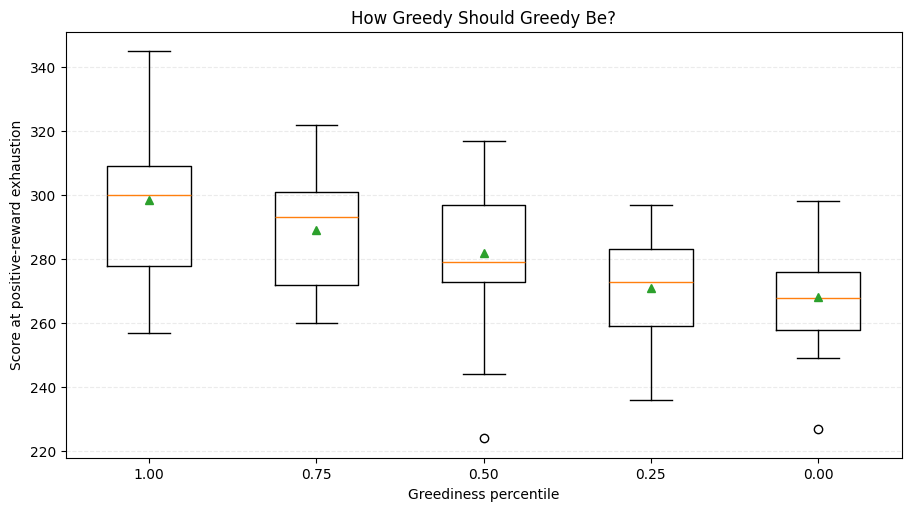

In [7]:
# Final-Score Distribution by Greediness

figure, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)

data = [
    runs.loc[runs["greediness"] == level, "final_score"].to_numpy()
    for level in GREEDINESS_LEVELS
]

axis.boxplot(
    data,
    tick_labels=[f"{level:.2f}" for level in GREEDINESS_LEVELS],
    showmeans=True,
)
axis.set_xlabel("Greediness percentile")
axis.set_ylabel("Score at positive-reward exhaustion")
axis.set_title("How Greedy Should Greedy Be?")
axis.grid(axis="y", linestyle="--", alpha=0.25)
axis.set_axisbelow(True)
plt.show()